In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
import os

print(os.getcwd())

C:\Users\Saiteja S\python\OnlineRetailAnalysis\notebooks


In [3]:
import pandas as pd

df = pd.read_excel("../data/Online Retail.xlsx")


print(df.head())
print(df.shape)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
(541909, 8)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(5268)

In [7]:
df = df.dropna(subset=['CustomerID'])

In [8]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [9]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [10]:
df = df.drop_duplicates()

In [11]:
df['Sales'] = df['Quantity'] * df['UnitPrice']

In [12]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [13]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

In [14]:
df['Month'] = df['InvoiceDate'].dt.month_name()

In [15]:
df['Sales'].sum()


np.float64(8887208.894000001)

In [16]:
df['InvoiceNo'].nunique()

18532

In [17]:
df['CustomerID'].nunique()

4338

In [18]:
df.groupby('InvoiceNo')['Sales'].sum().mean()

np.float64(479.56016047917126)

In [19]:
monthly_sales = df.groupby('YearMonth')['Sales'].sum()

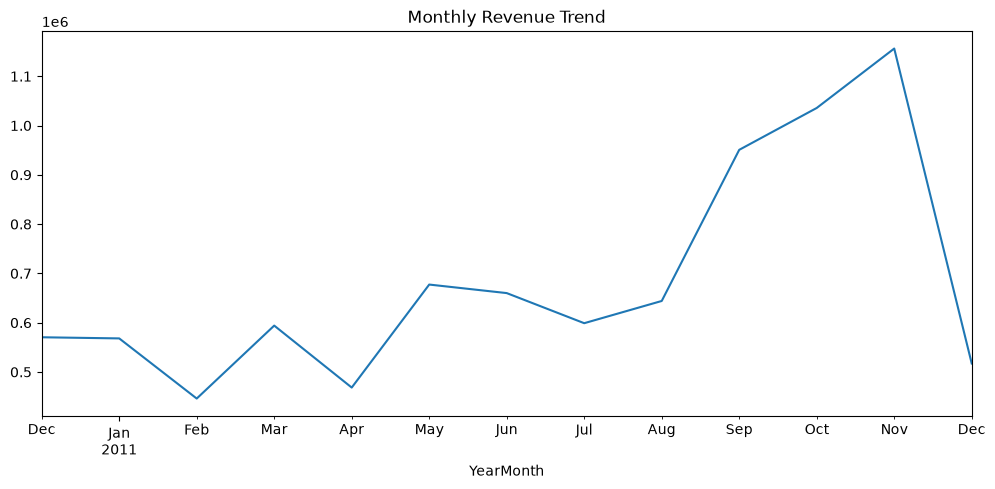

In [20]:
monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Revenue Trend")
plt.show()

In [21]:
top_products = (
    df.groupby('Description')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

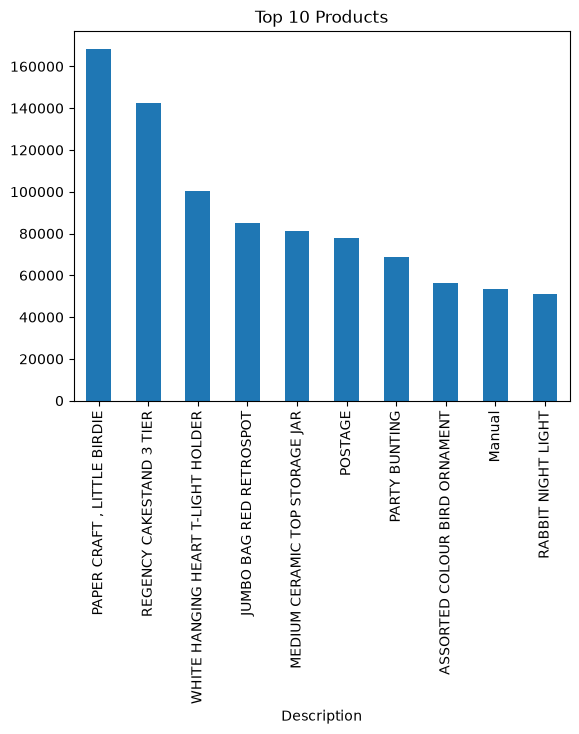

In [22]:
top_products.plot(kind='bar')
plt.title("Top 10 Products")
plt.show()

In [23]:
country_sales = (
    df.groupby('Country')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
country_sales

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Sales, dtype: float64

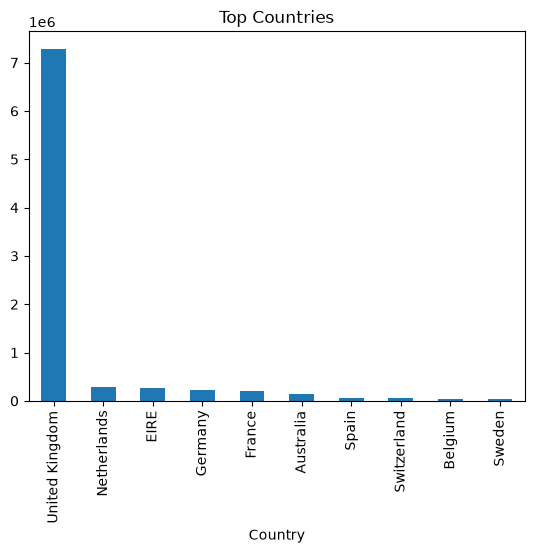

In [24]:
country_sales.plot(kind='bar')
plt.title("Top Countries")
plt.show()

In [25]:
top_customers = (
    df.groupby('CustomerID')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

In [26]:
top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Sales, dtype: float64

In [27]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [28]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Sales': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']

In [29]:
rfm

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
...,...,...,...
18280.0,278,1,180.60
18281.0,181,1,80.82
18282.0,8,2,178.05


## RFM Scoring and Customer Segmentation

In [30]:
r_labels = range(4, 0, -1)  # 4 = most recent (best), 1 = least recent
f_labels = range(1, 5)      # 4 = most frequent (best)
m_labels = range(1, 5)      # 4 = highest spend (best)

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=r_labels).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=f_labels).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=m_labels).astype(int)

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,6
12347.0,2,7,4310.00,4,4,4,444,12
12348.0,75,4,1797.24,2,3,4,234,9
12349.0,19,1,1757.55,3,1,4,314,8
12350.0,310,1,334.40,1,1,2,112,4


In [31]:
def segment_customer(total):
    if total >= 10:
        return 'Champions'
    elif total >= 8:
        return 'Loyal Customers'
    elif total >= 6:
        return 'Potential Loyalists'
    elif total >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Total'].apply(segment_customer)
rfm['Segment'].value_counts()

Segment
Champions              1267
At Risk                 991
Potential Loyalists     935
Loyal Customers         845
Lost                    300
Name: count, dtype: int64

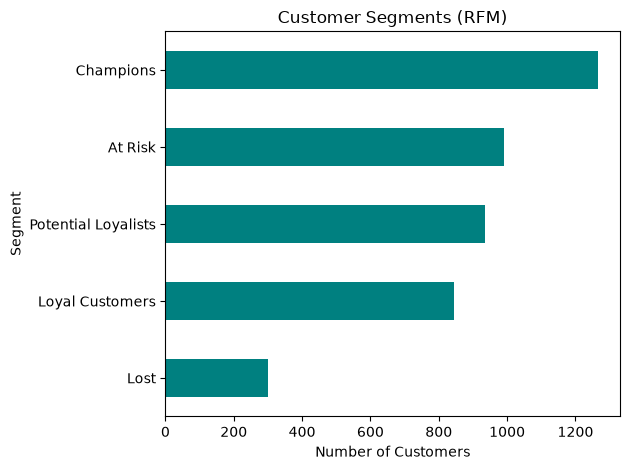

In [32]:
rfm['Segment'].value_counts().sort_values().plot(kind='barh', color='teal')
plt.title('Customer Segments (RFM)')
plt.xlabel('Number of Customers')
plt.tight_layout()
plt.show()

In [33]:
rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().sort_values('Monetary', ascending=False)

,Recency,Frequency,Monetary
Segment,,,
Champions,19.915549,9.921863,5388.504949
Loyal Customers,52.459172,3.230769,1244.497019
Potential Loyalists,87.293048,1.863102,695.753104
At Risk,171.437941,1.199798,312.296429
Lost,267.826667,1.000000,161.194100


## Pareto Analysis (80/20 Rule)

In [34]:
customer_sales = df.groupby('CustomerID')['Sales'].sum().sort_values(ascending=False)
cum_pct = customer_sales.cumsum() / customer_sales.sum()
pareto_customers = int((cum_pct <= 0.80).sum())

print(f"{pareto_customers} of {len(customer_sales)} customers "
      f"({pareto_customers / len(customer_sales) * 100:.1f}%) generate 80% of total revenue")

1129 of 4338 customers (26.0%) generate 80% of total revenue


## Monthly Cohort Retention

In [35]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceMonth'].transform('min')

cohort_index = (
    (df['InvoiceMonth'].dt.year - df['CohortMonth'].dt.year) * 12
    + (df['InvoiceMonth'].dt.month - df['CohortMonth'].dt.month)
)
df['CohortIndex'] = cohort_index

cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0)
retention.round(3)

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.366,0.323,0.384,0.363,0.398,0.363,0.349,0.354,0.395,0.374,0.503,0.266
2011-01,1.0,0.221,0.266,0.230,0.321,0.288,0.247,0.242,0.300,0.326,0.365,0.118,NaN
2011-02,1.0,0.187,0.187,0.284,0.271,0.247,0.253,0.279,0.247,0.305,0.068,NaN,NaN
2011-03,1.0,0.150,0.252,0.199,0.223,0.168,0.268,0.230,0.279,0.086,NaN,NaN,NaN
2011-04,1.0,0.213,0.203,0.210,0.197,0.227,0.217,0.260,0.073,NaN,NaN,NaN,NaN
2011-05,1.0,0.190,0.173,0.173,0.208,0.232,0.264,0.095,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.174,0.157,0.264,0.231,0.335,0.095,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.181,0.207,0.223,0.271,0.112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.207,0.249,0.243,0.124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


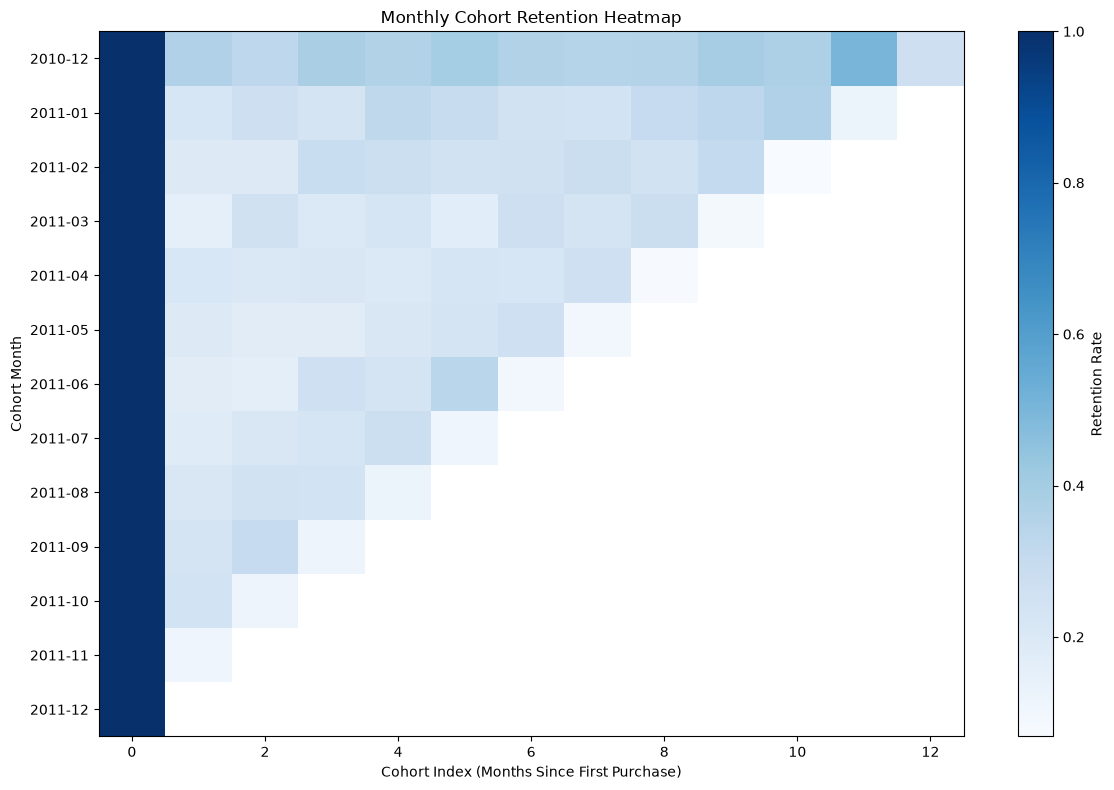

In [36]:
plt.figure(figsize=(12, 8))
plt.imshow(retention, cmap='Blues', aspect='auto')
plt.colorbar(label='Retention Rate')
plt.title('Monthly Cohort Retention Heatmap')
plt.xlabel('Cohort Index (Months Since First Purchase)')
plt.ylabel('Cohort Month')
plt.yticks(range(len(retention.index)), [str(i) for i in retention.index])
plt.tight_layout()
plt.show()

## Export Cleaned Data for Reporting (Power BI)

In [37]:
df.to_csv('../data/cleaned_online_retail.csv', index=False)
rfm.reset_index().to_csv('../data/rfm_segments.csv', index=False)
print('Exported cleaned transactions to data/cleaned_online_retail.csv')
print('Exported RFM segments to data/rfm_segments.csv')

Exported cleaned transactions to data/cleaned_online_retail.csv
Exported RFM segments to data/rfm_segments.csv
